# Prepare Data

## Import preprocessed data
Important things to note:
- "Track_genre" target is UNCHANGED (114 possible designations)
- Train/test split is implemented
- Categorical features are specified to be encoded in a fitting manner (in this case, one-hot encoded)
- Numeric features will be left alone

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('data//1_preprocessed//preprocessed_dataset.csv')

y = data.track_genre
X = data[['duration_ms','explicit','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']]

# Categorical features (will want to one-hot encode these): 'key', 'mode', 'time_signature'
categorical_cols = ['key', 'mode', 'time_signature']
print("Cardinality of categorical columns:")
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()}")
# Only key (12) may have too high of a cardinality, especially since it's already likely not a very important feature, so we'll drop it.
categorical_cols.remove('key')
X.drop(columns=['key'], inplace=True)

# Stratified split to maintain class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)


numerical_cols = ['duration_ms','explicit','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']
print("Numerical columns:", numerical_cols)

Cardinality of categorical columns:
key: 12
mode: 2
time_signature: 5
Numerical columns: ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


# 

## Begin model preprocessing
- One hot encoding occurs for categorical columns
- Numerical columns are left alone (no scaling/normalization necessary for Decision Tree-based model structure)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'  # Keep the numerical columns as they are; already preprocessed
)

# Random Forest model
## Training

In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0, verbose=True)
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

my_pipeline.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   17.7s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   43.2s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## Evaluation
### Classification Report
For both testing AND training accuracy

In [4]:
from sklearn.metrics import classification_report

train_preds = my_pipeline.predict(X_train)
print("Training Accuracy:", (train_preds == y_train).mean())
train_report = classification_report(y_train, train_preds, output_dict=True)
df_train_report = pd.DataFrame(train_report).T
print(df_train_report.sort_values("f1-score").head(20))  # worst performing genres in training set

test_preds = my_pipeline.predict(X_test)
print("Testing Accuracy:", (test_preds == y_test).mean())
test_report = classification_report(y_test, test_preds, output_dict=True)
df_test_report = pd.DataFrame(test_report).T
print(df_test_report.sort_values("f1-score").head(20))  # worst performing genres in test set

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.1s finished


Training Accuracy: 0.8172921322339524
                   precision    recall  f1-score  support
reggae              0.404959  0.428750  0.416515    800.0
reggaeton           0.425799  0.466250  0.445107    800.0
latino              0.443833  0.506918  0.473282    795.0
singer-songwriter   0.482097  0.471250  0.476612    800.0
songwriter          0.453725  0.502500  0.476868    800.0
latin               0.544025  0.436869  0.484594    792.0
edm                 0.485750  0.493082  0.489388    795.0
alternative         0.508701  0.475594  0.491591    799.0
indie               0.523142  0.467419  0.493713    798.0
alt-rock            0.516600  0.486859  0.501289    799.0
house               0.550685  0.503129  0.525834    799.0
metal               0.529480  0.573217  0.550481    799.0
rock                0.607143  0.552500  0.578534    800.0
punk                0.584767  0.595745  0.590205    799.0
indie-pop           0.597205  0.587500  0.592313    800.0
punk-rock           0.617128  0.61

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s


Testing Accuracy: 0.2539409951563188
                   precision    recall  f1-score  support
brazil              0.013793  0.010000  0.011594    200.0
electronic          0.023529  0.010000  0.014035    200.0
alt-rock            0.018293  0.015000  0.016484    200.0
punk-rock           0.021739  0.020000  0.020833    200.0
groove              0.050420  0.030000  0.037618    200.0
singer-songwriter   0.037383  0.040000  0.038647    200.0
punk                0.043011  0.040000  0.041451    200.0
j-rock              0.047120  0.045000  0.046036    200.0
songwriter          0.045643  0.055000  0.049887    200.0
metal               0.050251  0.050251  0.050251    199.0
mpb                 0.064865  0.060000  0.062338    200.0
hard-rock           0.072727  0.060000  0.065753    200.0
edm                 0.066667  0.065657  0.066158    198.0
indie-pop           0.085106  0.060000  0.070381    200.0
latino              0.072072  0.080808  0.076190    198.0
goth                0.110092  0.060

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.3s finished


81.7% training accuracy

25.4% testing accuracy

# Visualizations
## Accuracy Bar Chart

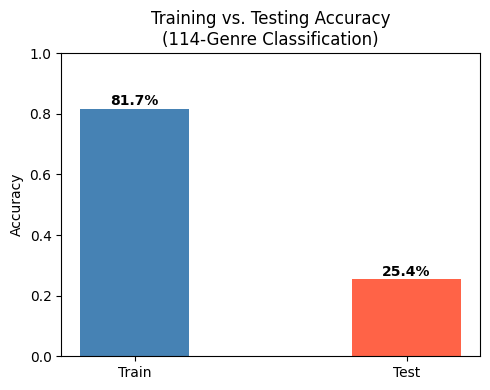

In [5]:
import matplotlib.pyplot as plt

train_acc = (train_preds == y_train).mean()
test_acc = (test_preds == y_test).mean()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Train', 'Test'], [train_acc, test_acc], color=['steelblue', 'tomato'], width=0.4)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Training vs. Testing Accuracy\n(114-Genre Classification)')
for bar, val in zip(bars, [train_acc, test_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Per genre F1 Score

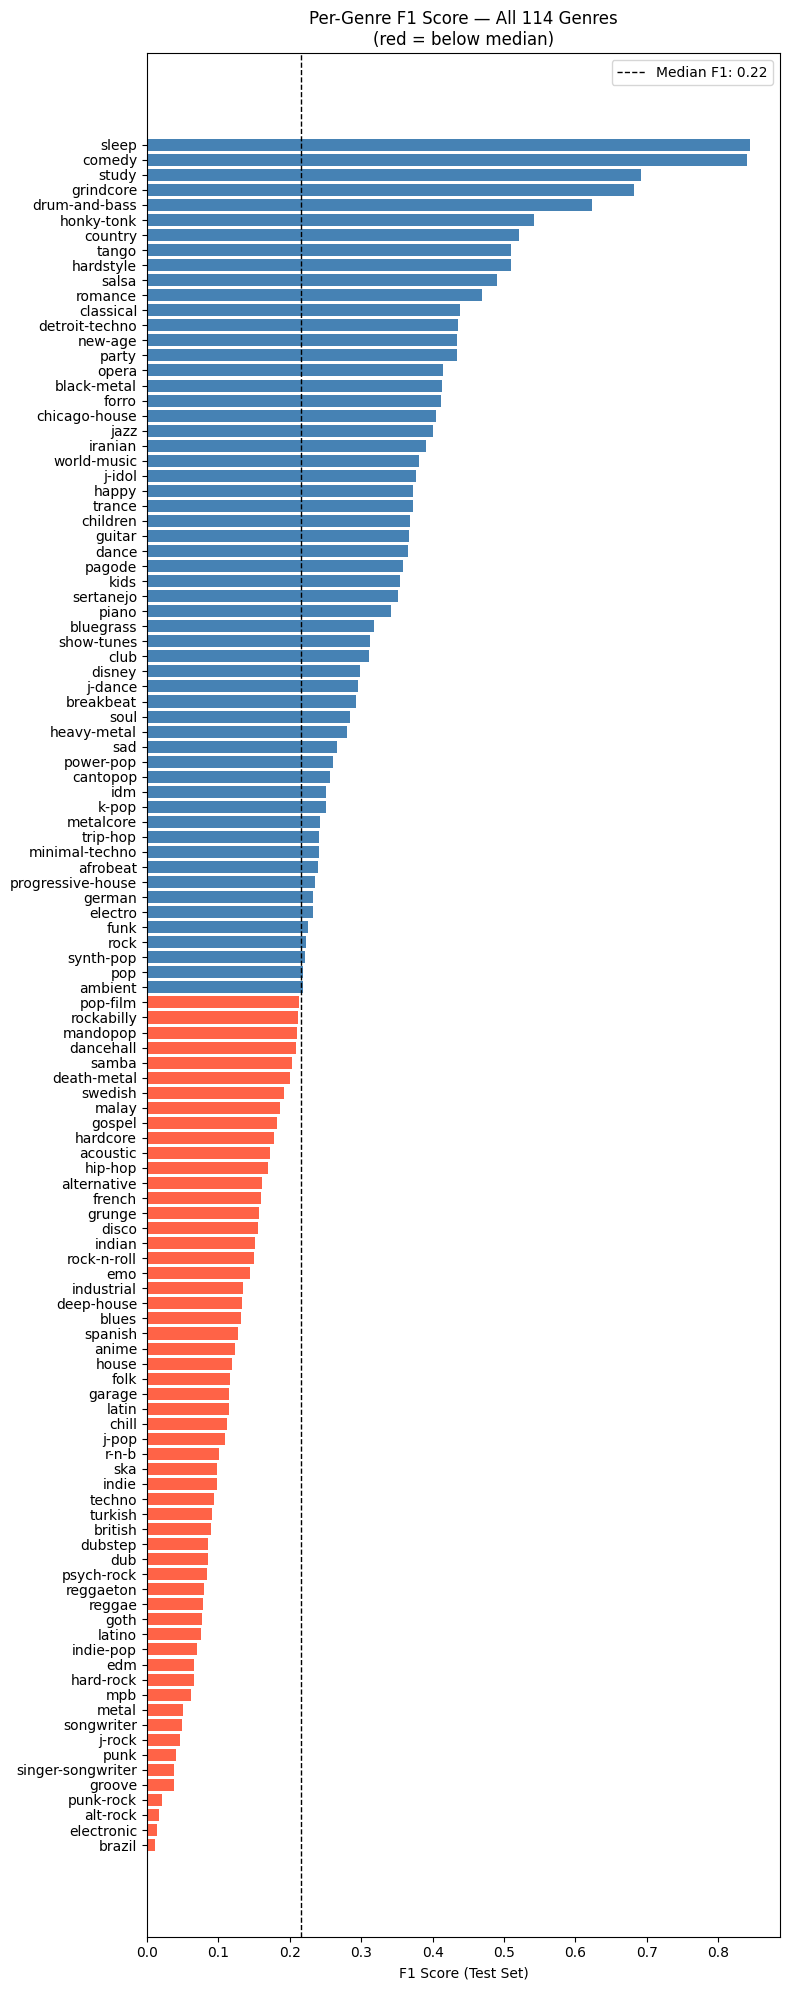

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

summary_rows = {'accuracy', 'macro avg', 'weighted avg'}
genre_f1 = {genre: metrics['f1-score']
            for genre, metrics in test_report.items()
            if genre not in summary_rows}

f1_series = pd.Series(genre_f1).sort_values()
median_f1 = f1_series.median()
colors = ['tomato' if v < median_f1 else 'steelblue' for v in f1_series.values]

fig, ax = plt.subplots(figsize=(8, 20))
ax.barh(f1_series.index, f1_series.values, color=colors)
ax.axvline(median_f1, color='black', linestyle='--', linewidth=1,
           label=f'Median F1: {median_f1:.2f}')
ax.set_xlabel('F1 Score (Test Set)')
ax.set_title('Per-Genre F1 Score — All 114 Genres\n(red = below median)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

This actually aligns incredibly well with the earlier heatmap, where genres such as sleep, study, and comedy are highly distinct while others do not have clearly identifiable different features.

## Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_preds)
cm_df = pd.DataFrame(cm, index=my_pipeline.named_steps['model'].classes_, columns=my_pipeline.named_steps['model'].classes_)
cm_df

,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
acoustic,34,1,0,0,1,1,1,8,2,0,...,1,1,4,2,4,0,0,1,1,4
afrobeat,0,44,0,1,0,0,0,4,0,1,...,1,4,0,3,2,0,1,8,3,0
alt-rock,1,1,3,47,0,1,0,0,4,2,...,1,0,0,2,0,0,0,0,2,5
alternative,2,0,57,32,0,1,0,0,1,0,...,0,1,0,0,0,0,0,2,1,0
ambient,2,0,0,0,43,2,2,2,0,0,...,0,0,1,0,2,1,0,3,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
techno,0,1,0,0,1,0,0,1,0,0,...,1,1,0,0,0,17,10,2,0,0
trance,0,0,0,0,0,1,2,0,0,0,...,0,0,1,0,0,9,82,2,0,1
trip-hop,0,8,0,2,3,0,1,3,2,0,...,0,5,2,6,2,0,0,45,1,2
turkish,0,2,2,0,0,1,1,2,0,0,...,2,1,2,1,4,0,0,4,15,0


Too large to visualize properly in seaborn/matplot

## Feature Importance (easily extracted from the Random Forest model)

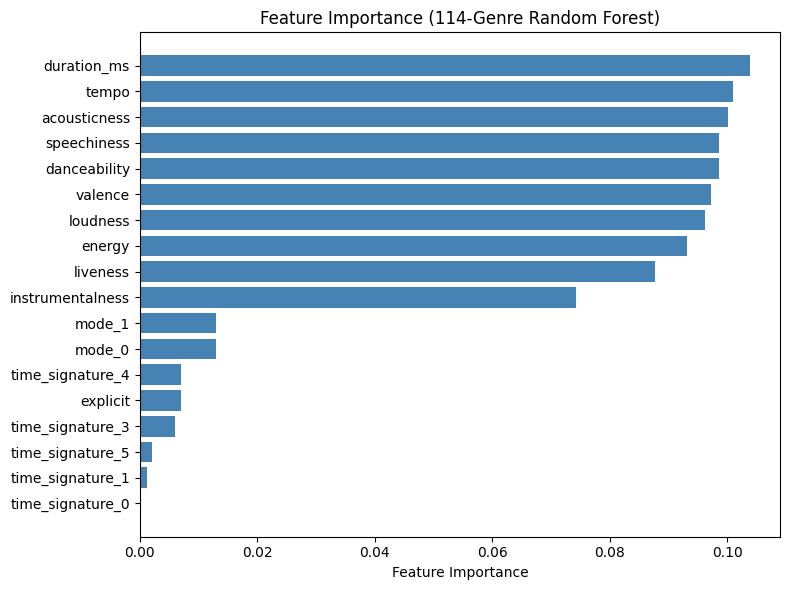

In [8]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = my_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = my_pipeline.named_steps['model'].feature_importances_

# Strip ColumnTransformer/Pipeline prefix (e.g. "cat__onehot__mode_0" → "mode_0")
clean_names = [n.split('__')[-1] for n in feature_names]
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([clean_names[i] for i in indices], importances[indices], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance (114-Genre Random Forest)')
plt.tight_layout()
plt.show()

The categorical columns were of fairly low importance compared to the numeric data.